# Project submission

### Group number:
### Student IDs:
### Project name: Crypto Future Price Estimate for Market Making


## What business problem are you solving?

As one of the most volatile assets, crypto assets pose a severe risk for any kind of firm involved in crypto trading activity, such as centralized exchanges like Coinbase or Binance, crypto asset management firms, or venture capitals like a16z, or traditional finance firms and financial services providers such as Revolut that allow users to trade assets.

In order to decrease inventory risk and also allow firms to take an informed stance on the future price of crypto assets, we want to create a simple model which, via a simple regression, allows the prediction of future asset prices. This would allow any business user to request a price prediction via a simple Excel spreadsheet or Python script. However, the difficulty lies in determining which features are actually important for the regression and which are just noise.

## What is the machine learning problem that you are solving?

The machine learning problem we are trying to solve is relatively simple. What we are trying to do is build a simple regression model, specifically a Ridge regression or L2 penalization model, to predict the future price. The actual difficulty lies not in performing the regression itself, but in finding which parameters are actually important.
Therefore, we start by clustering the assets into different groups so that we can find features that are important per class. 

After this, we develop trees of different depths to see which features actually hold, and develop SHAP values, ICE plots, and PDP plots to further analyze which features are important and which are just noise that can be neglected.
The actual difficulty here is to not overfit, but also to generalize well, while still making sure that the model is accurate and not too generalized

## Data exploration and preparation

We start with the same style used in the class notebooks: basic imports, `pandas` data checks, simple visualizations, and `sklearn` models.


In [15]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import Ridge
from sklearn.metrics import davies_bouldin_score, mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
sns.set(style="whitegrid")


### Load the data

In [16]:
df_raw = pd.read_csv("pr15_crypto.csv")

if "Unnamed: 0" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Unnamed: 0"])

df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])

print("Shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.dtypes)

Shape: (104324, 11)


,Asset_ID,timestamp,Count,Open,High,Low,Close,Volume,VWAP,Weight,Asset_Name
0,0,2018-01-01 00:00:00,3272.0,8.5300,8.5300,8.1305,8.3401,136150.46,8.327702,4.304065,Binance Coin
1,0,2018-01-01 04:00:00,3231.0,8.3612,8.7000,8.3410,8.3600,100304.70,8.485586,4.304065,Binance Coin
2,0,2018-01-01 08:00:00,3412.0,8.3852,8.5300,8.0703,8.1604,113605.91,8.274129,4.304065,Binance Coin
3,0,2018-01-01 12:00:00,3678.0,8.1800,8.3300,7.8000,8.1101,156761.84,8.063121,4.304065,Binance Coin
4,0,2018-01-01 16:00:00,2030.0,8.1160,8.1778,7.9592,8.1150,61915.82,8.063309,4.304065,Binance Coin


Asset_ID               int64
timestamp     datetime64[ns]
Count                float64
Open                 float64
High                 float64
Low                  float64
Close                float64
Volume               float64
VWAP                 float64
Weight               float64
Asset_Name            object
dtype: object

In [17]:
try:
    data_dictionary = pd.read_excel("pr15_data_dictionary.xlsx")
    display(data_dictionary)
except ImportError:
    print("The data dictionary is an Excel file. Install openpyxl to display it in this notebook.")

The data dictionary is an Excel file. Install openpyxl to display it in this notebook.


### Basic data checks

We check rows, duplicates, missing values, infinite values, asset coverage, and the time range.

In [18]:
print("Number of rows:", len(df_raw))
print("Number of duplicate rows:", df_raw.duplicated().sum())
print("Date range:", df_raw["timestamp"].min(), "to", df_raw["timestamp"].max())
print("Number of assets:", df_raw["Asset_Name"].nunique())

display(df_raw.isna().sum().to_frame("missing_values"))

numeric_columns_raw = df_raw.select_dtypes(include="number").columns
inf_counts = np.isinf(df_raw[numeric_columns_raw]).sum()
display(inf_counts[inf_counts > 0].to_frame("infinite_values"))

Number of rows: 104324
Number of duplicate rows: 0
Date range: 2018-01-01 00:00:00 to 2021-09-20 20:00:00
Number of assets: 14


,missing_values
Asset_ID,0
timestamp,0
Count,0
Open,0
High,0
Low,0
Close,0
Volume,0
VWAP,0
Weight,0


,infinite_values
VWAP,6


In [19]:
asset_summary = (
    df_raw.groupby("Asset_Name")
    .agg(
        rows=("Close", "size"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
        min_close=("Close", "min"),
        max_close=("Close", "max"),
    )
    .sort_values("rows", ascending=False)
)

display(asset_summary)

,rows,first_timestamp,last_timestamp,min_close,max_close
Asset_Name,,,,,
Bitcoin,8154,2018-01-01 00:00:00,2021-09-20 20:00:00,3165.973333,64530.898571
Bitcoin Cash,8154,2018-01-01 00:00:00,2021-09-20 20:00:00,74.460000,2856.856667
EOS.IO,8154,2018-01-01 00:00:00,2021-09-20 20:00:00,1.663300,22.504250
Ethereum,8154,2018-01-01 00:00:00,2021-09-20 20:00:00,82.298250,4334.685714
Ethereum Classic,8154,2018-01-01 00:00:00,2021-09-20 20:00:00,3.407050,148.242700
Litecoin,8154,2018-01-01 00:00:00,2021-09-20 20:00:00,22.850750,409.043000
Monero,8152,2018-01-01 00:00:00,2021-09-20 20:00:00,30.225000,515.620000
Binance Coin,8140,2018-01-01 00:00:00,2021-09-20 20:00:00,4.316300,683.385000
TRON,7933,2018-02-06 20:00:00,2021-09-20 20:00:00,0.008507,0.174305


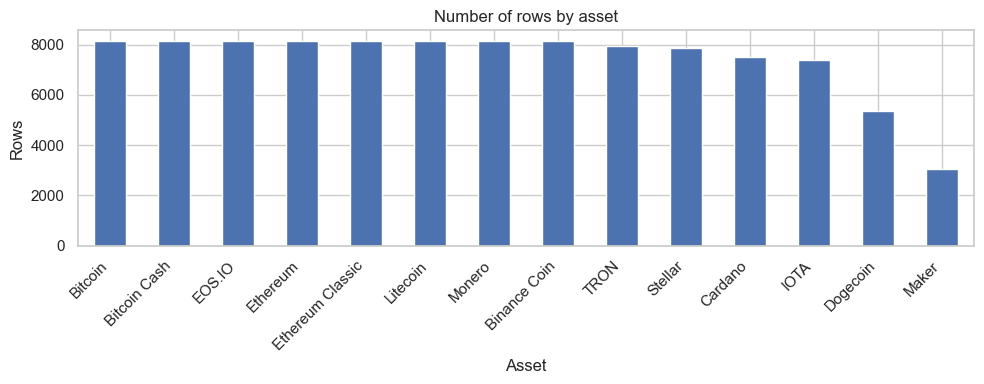

In [20]:
plt.figure(figsize=(10, 4))
df_raw["Asset_Name"].value_counts().plot(kind="bar")
plt.title("Number of rows by asset")
plt.ylabel("Rows")
plt.xlabel("Asset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

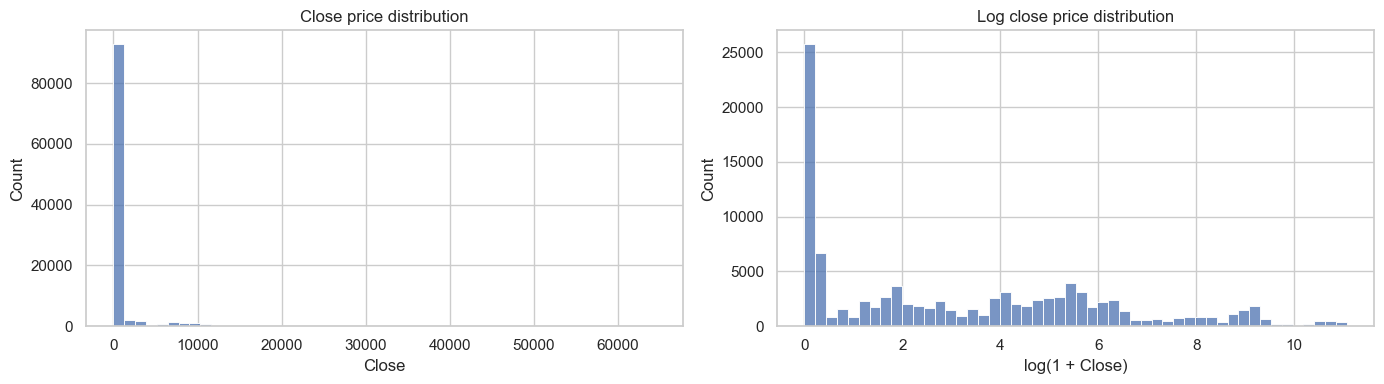

In [21]:
close_for_plot = pd.to_numeric(df_raw["Close"], errors="coerce")
close_for_plot = close_for_plot.replace([np.inf, -np.inf], np.nan).dropna()

close_bins = np.linspace(close_for_plot.min(), close_for_plot.max(), 51)
log_close_for_plot = np.log1p(close_for_plot)
log_close_bins = np.linspace(log_close_for_plot.min(), log_close_for_plot.max(), 51)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(close_for_plot, bins=close_bins, ax=axes[0])
axes[0].set_title("Close price distribution")
axes[0].set_xlabel("Close")

sns.histplot(log_close_for_plot, bins=log_close_bins, ax=axes[1])
axes[1].set_title("Log close price distribution")
axes[1].set_xlabel("log(1 + Close)")

plt.tight_layout()
plt.show()

The dataset has no missing values and no duplicate rows. `VWAP` has a few infinite values, so those rows are removed before feature engineering.

## Clustering the assets

First we cluster the assets. The goal is to group assets with similar historical behavior before doing regression. We compare a few clustering methods, but keep KMeans as the cluster feature because it is simple and easy to explain.

The clustering summaries are built using only the earlier part of the sample, roughly the same period as the training data.

In [22]:
cluster_training_cutoff = df_raw["timestamp"].quantile(0.70)

df_cluster = df_raw[df_raw["timestamp"] <= cluster_training_cutoff].sort_values(
    ["Asset_ID", "timestamp"]
).copy()

numeric_columns = df_cluster.select_dtypes(include="number").columns
df_cluster[numeric_columns] = df_cluster[numeric_columns].replace([np.inf, -np.inf], np.nan)
df_cluster = df_cluster.dropna(subset=["Close", "Volume", "VWAP", "Count"])

asset_group_cluster = df_cluster.groupby("Asset_ID", group_keys=False)
df_cluster["return_4h"] = asset_group_cluster["Close"].pct_change()

asset_cluster_features = (
    df_cluster.groupby(["Asset_ID", "Asset_Name"])
    .agg(
        mean_close=("Close", "mean"),
        mean_volume=("Volume", "mean"),
        mean_count=("Count", "mean"),
        mean_return_4h=("return_4h", "mean"),
        volatility_4h=("return_4h", "std"),
        worst_return_4h=("return_4h", "min"),
    )
    .reset_index()
)

for column in ["mean_close", "mean_volume", "mean_count"]:
    asset_cluster_features[f"log_{column}"] = np.log1p(asset_cluster_features[column])

cluster_feature_columns = [
    "log_mean_close",
    "log_mean_volume",
    "log_mean_count",
    "mean_return_4h",
    "volatility_4h",
    "worst_return_4h",
]

asset_cluster_features = asset_cluster_features.dropna(subset=cluster_feature_columns)

print("Clustering uses data up to:", cluster_training_cutoff)
display(asset_cluster_features[["Asset_Name"] + cluster_feature_columns])

Clustering uses data up to: 2020-09-13 08:00:00


,Asset_Name,log_mean_close,log_mean_volume,log_mean_count,mean_return_4h,volatility_4h,worst_return_4h
0,Binance Coin,2.842460,12.899740,9.358667,0.000487,0.023543,-0.226789
1,Bitcoin,8.970966,9.957915,11.899587,0.000086,0.016173,-0.199033
2,Bitcoin Cash,6.185258,10.673766,10.063616,-0.000083,0.024990,-0.273476
3,Cardano,0.078444,17.861483,9.465949,0.000047,0.021719,-0.217697
4,Dogecoin,0.002624,18.419416,7.619103,0.000165,0.018414,-0.169656
5,EOS.IO,1.816057,15.354811,10.561959,0.000143,0.025098,-0.214668
6,Ethereum,5.728074,12.363909,11.266628,0.000098,0.020621,-0.213085
7,Ethereum Classic,2.387977,13.312525,9.515300,-0.000020,0.023738,-0.254540
8,IOTA,0.344924,14.405952,7.997145,-0.000165,0.022147,-0.244429
9,Litecoin,4.367147,12.223703,10.178603,-0.000021,0.021591,-0.203757


### Choosing and comparing clusters

Following the clustering notebook, we scale the features first and compare cluster quality with the elbow method, silhouette score, and Davies-Bouldin index.

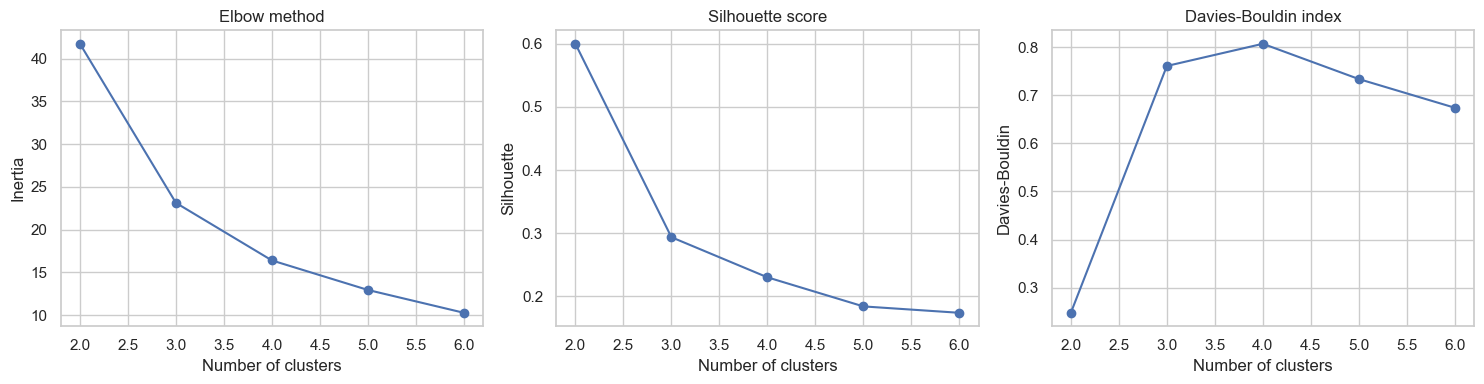

,k,inertia,silhouette_score,davies_bouldin_score
0,2,41.738151,0.600074,0.247576
1,3,23.131091,0.293634,0.761084
2,4,16.400367,0.230087,0.807254
3,5,12.946830,0.183980,0.733886
4,6,10.275420,0.173846,0.674174


In [23]:
cluster_scaler = StandardScaler()
X_assets_scaled = cluster_scaler.fit_transform(asset_cluster_features[cluster_feature_columns])

k_values = range(2, 7)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    cluster_labels = kmeans.fit_predict(X_assets_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_assets_scaled, cluster_labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_assets_scaled, cluster_labels))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(list(k_values), inertias, marker="o")
ax[0].set_title("Elbow method")
ax[0].set_xlabel("Number of clusters")
ax[0].set_ylabel("Inertia")

ax[1].plot(list(k_values), silhouette_scores, marker="o")
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("Number of clusters")
ax[1].set_ylabel("Silhouette")

ax[2].plot(list(k_values), davies_bouldin_scores, marker="o")
ax[2].set_title("Davies-Bouldin index")
ax[2].set_xlabel("Number of clusters")
ax[2].set_ylabel("Davies-Bouldin")

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores,
    "davies_bouldin_score": davies_bouldin_scores,
}))

In [24]:
chosen_k = 3

clustering_models = {
    "KMeans": KMeans(n_clusters=chosen_k, random_state=SEED, n_init=20),
    "Agglomerative": AgglomerativeClustering(n_clusters=chosen_k),
    "DBSCAN": DBSCAN(eps=1.5, min_samples=2),
}

clustering_results = []

for method_name, clustering_model in clustering_models.items():
    labels = clustering_model.fit_predict(X_assets_scaled)
    labels_for_score = labels[labels != -1]
    X_for_score = X_assets_scaled[labels != -1]
    n_clusters = len(set(labels_for_score))
    n_noise = (labels == -1).sum()

    if n_clusters > 1 and len(labels_for_score) > n_clusters:
        silhouette = silhouette_score(X_for_score, labels_for_score)
        davies_bouldin = davies_bouldin_score(X_for_score, labels_for_score)
    else:
        silhouette = np.nan
        davies_bouldin = np.nan

    asset_cluster_features[f"{method_name}_cluster"] = labels
    clustering_results.append({
        "method": method_name,
        "number_of_clusters": n_clusters,
        "noise_points": n_noise,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies_bouldin,
    })

clustering_results = pd.DataFrame(clustering_results)
display(clustering_results)

asset_cluster_features["asset_cluster"] = asset_cluster_features["KMeans_cluster"]
display(asset_cluster_features[["Asset_ID", "Asset_Name", "asset_cluster"]].sort_values(["asset_cluster", "Asset_Name"]))

,method,number_of_clusters,noise_points,silhouette_score,davies_bouldin_score
0,KMeans,3,0,0.293634,0.761084
1,Agglomerative,3,0,0.281457,0.729197
2,DBSCAN,1,5,NaN,NaN


,Asset_ID,Asset_Name,asset_cluster
1,1,Bitcoin,0
2,2,Bitcoin Cash,0
6,6,Ethereum,0
9,9,Litecoin,0
11,11,Monero,0
10,10,Maker,1
0,0,Binance Coin,2
3,3,Cardano,2
4,4,Dogecoin,2
5,5,EOS.IO,2


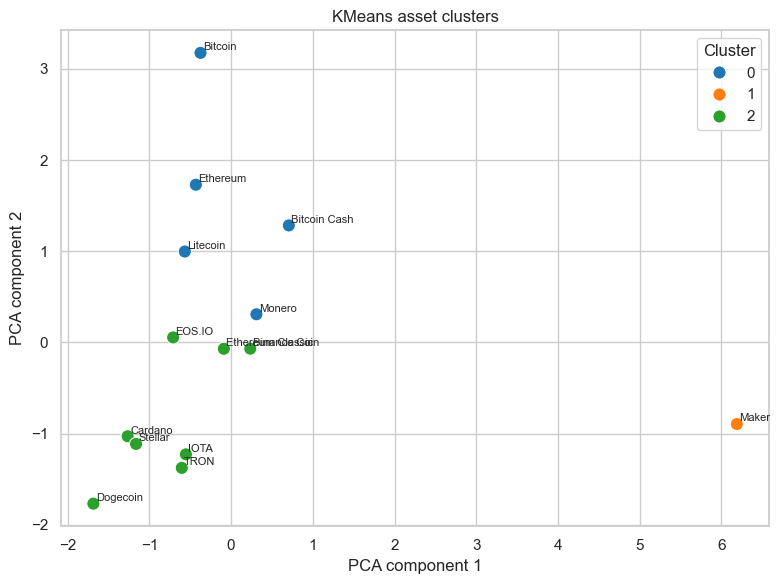

In [25]:
pca = PCA(n_components=2, random_state=SEED)
asset_pca = pca.fit_transform(X_assets_scaled)

asset_cluster_features["pca_1"] = asset_pca[:, 0]
asset_cluster_features["pca_2"] = asset_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=asset_cluster_features,
    x="pca_1",
    y="pca_2",
    hue="asset_cluster",
    palette="tab10",
    s=90,
)

for _, row in asset_cluster_features.iterrows():
    plt.text(row["pca_1"] + 0.03, row["pca_2"] + 0.03, row["Asset_Name"], fontsize=8)

plt.title("KMeans asset clusters")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## Feature engineering

For supervised learning, we create a historical future-price label from the realized price at the next timestamp. This label tells the model what it should have predicted. The realized future price is never included as an input feature.

The feature set stays simple: price, volume, candle, lag, rolling volatility, cross-asset, calendar, and cluster features. The cross-asset features include the average return of the other assets plus Bitcoin and Ethereum returns.

In [26]:
df = df_raw.sort_values(["Asset_ID", "timestamp"]).copy()

numeric_columns = df.select_dtypes(include="number").columns
df[numeric_columns] = df[numeric_columns].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Open", "High", "Low", "Close", "Volume", "VWAP", "Count", "Weight"])

asset_cluster_lookup = asset_cluster_features[["Asset_ID", "asset_cluster"]]
df = df.merge(asset_cluster_lookup, on="Asset_ID", how="left")

asset_group = df.groupby("Asset_ID", group_keys=False)

# Historical label for training: realized future price at the next timestamp.
# This column is the target, not an input feature.
df["future_price"] = asset_group["Close"].shift(-1)

df["candle_return"] = df["Close"] / df["Open"] - 1
df["high_low_range_pct"] = (df["High"] - df["Low"]) / df["Open"]
df["close_vwap_gap_pct"] = (df["Close"] - df["VWAP"]) / df["VWAP"]
df["volume_log"] = np.log1p(df["Volume"])
df["count_log"] = np.log1p(df["Count"])

df["return_4h"] = asset_group["Close"].pct_change(1)
df["return_8h"] = asset_group["Close"].pct_change(2)
df["return_24h"] = asset_group["Close"].pct_change(6)
df["rolling_return_mean_24h"] = asset_group["return_4h"].transform(
    lambda s: s.rolling(window=6, min_periods=3).mean()
)
df["rolling_volatility_24h"] = asset_group["return_4h"].transform(
    lambda s: s.rolling(window=6, min_periods=3).std()
)
df["rolling_volume_mean_24h"] = asset_group["Volume"].transform(
    lambda s: s.rolling(window=6, min_periods=3).mean()
)
df["volume_change_4h"] = asset_group["Volume"].pct_change(1)

timestamp_group = df.groupby("timestamp")
df["assets_at_timestamp"] = timestamp_group["return_4h"].transform("count")
df["market_return_4h"] = timestamp_group["return_4h"].transform("mean")
df["market_volatility_4h"] = timestamp_group["return_4h"].transform("std")
df["other_assets_return_4h"] = (
    df["market_return_4h"] * df["assets_at_timestamp"] - df["return_4h"]
) / (df["assets_at_timestamp"] - 1)

asset_return_table = df.pivot_table(index="timestamp", columns="Asset_Name", values="return_4h")
df["bitcoin_return_4h"] = df["timestamp"].map(asset_return_table["Bitcoin"])
df["ethereum_return_4h"] = df["timestamp"].map(asset_return_table["Ethereum"])

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month

candidate_features = [
    "asset_cluster",
    "Count",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "VWAP",
    "Weight",
    "candle_return",
    "high_low_range_pct",
    "close_vwap_gap_pct",
    "volume_log",
    "count_log",
    "return_4h",
    "return_8h",
    "return_24h",
    "rolling_return_mean_24h",
    "rolling_volatility_24h",
    "rolling_volume_mean_24h",
    "market_return_4h",
    "other_assets_return_4h",
    "market_volatility_4h",
    "bitcoin_return_4h",
    "ethereum_return_4h",
    "volume_change_4h",
    "hour",
    "day_of_week",
    "month",
]

df_model = df.dropna(subset=candidate_features + ["future_price"]).copy()
df_model = df_model.sort_values(["timestamp", "Asset_ID"]).reset_index(drop=True)

print("Shape after feature engineering:", df_model.shape)
display(df_model[["timestamp", "Asset_Name"] + candidate_features + ["future_price"]].head())

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

### Chronological 70/20/10 split

We keep the requested 70/20/10 proportions: 70% training, 20% test, and 10% validation. In the code, the most recent 20% is kept as the final test set, while the 10% validation period is between train and test.

In [ ]:
n_rows = len(df_model)

train_cutoff = df_model.loc[int(0.70 * n_rows) - 1, "timestamp"]
validation_cutoff = df_model.loc[int(0.80 * n_rows) - 1, "timestamp"]

train_df = df_model[df_model["timestamp"] <= train_cutoff].copy()
validation_df = df_model[
    (df_model["timestamp"] > train_cutoff)
    & (df_model["timestamp"] <= validation_cutoff)
].copy()
test_df = df_model[df_model["timestamp"] > validation_cutoff].copy()

split_summary = pd.DataFrame(
    {
        "rows": [len(train_df), len(test_df), len(validation_df)],
        "share": [len(train_df) / n_rows, len(test_df) / n_rows, len(validation_df) / n_rows],
        "start": [train_df["timestamp"].min(), test_df["timestamp"].min(), validation_df["timestamp"].min()],
        "end": [train_df["timestamp"].max(), test_df["timestamp"].max(), validation_df["timestamp"].max()],
    },
    index=["train", "test", "validation"],
)

display(split_summary)

## Feature importance by cluster

Now we decide which features are important for each cluster. We use decision trees with different depths. If a feature is important across several depths, it is a stronger feature candidate for that cluster.

In [ ]:
tree_depths = [2, 4, 6]
cluster_importance_rows = []
cluster_tree_scores = []

for cluster_id in sorted(train_df["asset_cluster"].unique()):
    cluster_train = train_df[train_df["asset_cluster"] == cluster_id]
    cluster_validation = validation_df[validation_df["asset_cluster"] == cluster_id]

    X_cluster_train = cluster_train[candidate_features]
    y_cluster_train = cluster_train["future_price"]

    for depth in tree_depths:
        tree = DecisionTreeRegressor(
            max_depth=depth,
            min_samples_leaf=100,
            random_state=SEED,
        )
        tree.fit(X_cluster_train, y_cluster_train)

        if len(cluster_validation) > 0:
            X_cluster_validation = cluster_validation[candidate_features]
            y_cluster_validation = cluster_validation["future_price"]
            y_pred = tree.predict(X_cluster_validation)

            cluster_tree_scores.append(
                {
                    "cluster": cluster_id,
                    "depth": depth,
                    "validation_MAE": mean_absolute_error(y_cluster_validation, y_pred),
                    "validation_RMSE": np.sqrt(mean_squared_error(y_cluster_validation, y_pred)),
                    "validation_R2": r2_score(y_cluster_validation, y_pred),
                }
            )

        for feature, importance in zip(candidate_features, tree.feature_importances_):
            cluster_importance_rows.append(
                {
                    "cluster": cluster_id,
                    "depth": depth,
                    "feature": feature,
                    "importance": importance,
                }
            )

cluster_tree_scores = pd.DataFrame(cluster_tree_scores)
cluster_importance_df = pd.DataFrame(cluster_importance_rows)

display(cluster_tree_scores)


In [ ]:
cluster_feature_importance = (
    cluster_importance_df.groupby(["cluster", "feature"])["importance"]
    .mean()
    .reset_index()
    .sort_values(["cluster", "importance"], ascending=[True, False])
)

display(cluster_feature_importance.groupby("cluster").head(10))

fig, axes = plt.subplots(
    1,
    len(sorted(cluster_feature_importance["cluster"].unique())),
    figsize=(16, 5),
    sharex=False,
)

if len(sorted(cluster_feature_importance["cluster"].unique())) == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, sorted(cluster_feature_importance["cluster"].unique())):
    top_features = cluster_feature_importance[cluster_feature_importance["cluster"] == cluster_id].head(8)
    sns.barplot(data=top_features, y="feature", x="importance", ax=ax, orient="h")
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Average importance")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

### SHAP, PDP, ICE, and final feature decisions

The decision trees give the first feature ranking. We then use SHAP, PDP, and ICE in the same style as the interpretability notebook to check which features should be kept and which features should be neglected.

The final Ridge models only use the features marked as `include in Ridge`. Features marked as `do not include in Ridge` are treated as noise or as not useful for an asset-specific regression.


In [ ]:
top_n_features = 8
features_not_for_final_regression = ["asset_cluster", "Weight"]

best_depth_by_cluster = (
    cluster_tree_scores.sort_values("validation_MAE")
    .groupby("cluster")["depth"]
    .first()
    .to_dict()
)

cluster_tree_models = {}

for cluster_id in sorted(train_df["asset_cluster"].unique()):
    depth = int(best_depth_by_cluster.get(cluster_id, 4))
    cluster_train = train_df[train_df["asset_cluster"] == cluster_id]

    tree = DecisionTreeRegressor(
        max_depth=depth,
        min_samples_leaf=100,
        random_state=SEED,
    )
    tree.fit(cluster_train[candidate_features], cluster_train["future_price"])
    cluster_tree_models[cluster_id] = tree

try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print("SHAP is not installed, so the feature decision uses tree importance only.")

cluster_shap_rows = []
shap_values_by_cluster = {}
shap_data_by_cluster = {}

if shap_available:
    for cluster_id, tree in cluster_tree_models.items():
        cluster_train = train_df[train_df["asset_cluster"] == cluster_id]
        shap_sample = cluster_train.sample(min(300, len(cluster_train)), random_state=SEED)
        X_shap = shap_sample[candidate_features]

        explainer = shap.TreeExplainer(tree)
        shap_values = explainer.shap_values(X_shap)

        shap_values_by_cluster[cluster_id] = shap_values
        shap_data_by_cluster[cluster_id] = X_shap

        shap_importance = np.abs(shap_values).mean(axis=0)
        for feature, importance in zip(candidate_features, shap_importance):
            cluster_shap_rows.append(
                {
                    "cluster": cluster_id,
                    "feature": feature,
                    "shap_importance": importance,
                }
            )

cluster_shap_importance = pd.DataFrame(cluster_shap_rows)

feature_decision_table = cluster_feature_importance.copy()
feature_decision_table["tree_rank"] = feature_decision_table.groupby("cluster")[
    "importance"
].rank(method="first", ascending=False)

if len(cluster_shap_importance) > 0:
    cluster_shap_importance["shap_rank"] = cluster_shap_importance.groupby("cluster")[
        "shap_importance"
    ].rank(method="first", ascending=False)
    feature_decision_table = feature_decision_table.merge(
        cluster_shap_importance,
        on=["cluster", "feature"],
        how="left",
    )
else:
    feature_decision_table["shap_importance"] = np.nan
    feature_decision_table["shap_rank"] = np.nan

feature_decision_table["eligible_for_final_model"] = ~feature_decision_table[
    "feature"
].isin(features_not_for_final_regression)
feature_decision_table["shap_rank_for_selection"] = feature_decision_table[
    "shap_rank"
].fillna(feature_decision_table["tree_rank"])
feature_decision_table["combined_rank"] = (
    feature_decision_table["tree_rank"]
    + feature_decision_table["shap_rank_for_selection"]
)
feature_decision_table["decision"] = "do not include in Ridge"
feature_decision_table["reason"] = "low importance compared with the selected features"
feature_decision_table.loc[
    ~feature_decision_table["eligible_for_final_model"],
    "reason",
] = "context or cluster feature, not used in the final one-asset Ridge model"

cluster_selected_features = {}
cluster_neglected_features = {}

for cluster_id in sorted(feature_decision_table["cluster"].unique()):
    cluster_rows = feature_decision_table[
        (feature_decision_table["cluster"] == cluster_id)
        & (feature_decision_table["eligible_for_final_model"])
    ].sort_values("combined_rank")

    selected_features = cluster_rows.head(top_n_features)["feature"].tolist()
    cluster_selected_features[cluster_id] = selected_features

    keep_mask = (
        (feature_decision_table["cluster"] == cluster_id)
        & (feature_decision_table["feature"].isin(selected_features))
    )
    feature_decision_table.loc[keep_mask, "decision"] = "include in Ridge"
    feature_decision_table.loc[
        keep_mask,
        "reason",
    ] = "selected from decision-tree importance and SHAP rank"

    cluster_neglected_features[cluster_id] = (
        feature_decision_table[
            (feature_decision_table["cluster"] == cluster_id)
            & (feature_decision_table["decision"] == "do not include in Ridge")
        ]["feature"]
        .tolist()
    )

feature_decision_table = feature_decision_table.sort_values(
    ["cluster", "decision", "combined_rank"],
    ascending=[True, True, True],
)

selected_features_table = pd.DataFrame(
    [
        {
            "cluster": cluster_id,
            "selected_features": selected_features,
            "neglected_features": cluster_neglected_features[cluster_id],
        }
        for cluster_id, selected_features in cluster_selected_features.items()
    ]
)

display(
    feature_decision_table[
        [
            "cluster",
            "feature",
            "tree_rank",
            "shap_rank",
            "combined_rank",
            "decision",
            "reason",
        ]
    ]
)
display(selected_features_table)


In [ ]:
for cluster_id, tree in cluster_tree_models.items():
    cluster_validation = validation_df[validation_df["asset_cluster"] == cluster_id]
    if len(cluster_validation) == 0:
        continue

    features_to_plot = cluster_selected_features[cluster_id][:2]
    X_plot = cluster_validation.sample(min(200, len(cluster_validation)), random_state=SEED)[
        candidate_features
    ]

    fig, ax = plt.subplots(figsize=(10, 4))
    PartialDependenceDisplay.from_estimator(
        tree,
        X_plot,
        features=features_to_plot,
        kind="both",
        ax=ax,
    )
    ax.set_title(f"Cluster {cluster_id}: PDP and ICE")
    plt.tight_layout()
    plt.show()


In [ ]:
if shap_available and len(shap_values_by_cluster) > 0:
    example_cluster = sorted(shap_values_by_cluster.keys())[0]
    print("SHAP summary for cluster:", example_cluster)
    shap.summary_plot(
        shap_values_by_cluster[example_cluster],
        shap_data_by_cluster[example_cluster],
        plot_type="bar",
    )

### Final include / neglect decision for Ridge Regression

This is the final decision step before the Ridge models. For each cluster, the table below shows exactly which features go into the Ridge regression and which features are left out.

A feature is included when it is one of the strongest features after the decision-tree and SHAP analysis. PDP and ICE plots are then used as a visual check for the strongest selected features. A feature is neglected when it has low support in the analysis or when it is useful for clustering/context but not useful inside a one-asset Ridge model.


In [ ]:
feature_selection_rule = pd.DataFrame(
    [
        {
            "decision": "include in Ridge",
            "rule": "eligible feature and ranked inside the top features for its cluster",
        },
        {
            "decision": "do not include in Ridge",
            "rule": "low feature importance or useful only for clustering/context",
        },
    ]
)

ridge_feature_decisions = (
    feature_decision_table[
        [
            "cluster",
            "feature",
            "decision",
            "tree_rank",
            "shap_rank",
            "combined_rank",
            "reason",
        ]
    ]
    .copy()
    .sort_values(["cluster", "decision", "combined_rank"])
)

ridge_features_by_cluster = {}
ridge_neglected_features_by_cluster = {}

for cluster_id in sorted(ridge_feature_decisions["cluster"].unique()):
    cluster_decisions = ridge_feature_decisions[
        ridge_feature_decisions["cluster"] == cluster_id
    ]
    ridge_features_by_cluster[cluster_id] = cluster_decisions[
        cluster_decisions["decision"] == "include in Ridge"
    ]["feature"].tolist()
    ridge_neglected_features_by_cluster[cluster_id] = cluster_decisions[
        cluster_decisions["decision"] == "do not include in Ridge"
    ]["feature"].tolist()

ridge_feature_summary = pd.DataFrame(
    [
        {
            "cluster": cluster_id,
            "features_included_in_ridge": ridge_features_by_cluster[cluster_id],
            "features_not_included_in_ridge": ridge_neglected_features_by_cluster[cluster_id],
        }
        for cluster_id in ridge_features_by_cluster
    ]
)

display(feature_selection_rule)
display(ridge_feature_decisions)
display(ridge_feature_summary)


## Asset-specific Ridge regressions

Finally, we train one Ridge Regression model per asset. The features are not chosen inside the Ridge loop. They come directly from the final include/neglect table above. Each asset looks up its cluster, takes only the features listed in `features_included_in_ridge`, and leaves out the features listed in `features_not_included_in_ridge`.


In [ ]:
ridge_alpha_values = [0.1, 1.0, 10.0, 100.0]

asset_models = {}
asset_model_rows = []
asset_alpha_rows = []
asset_prediction_frames = []

for asset_name in sorted(train_df["Asset_Name"].unique()):
    asset_train = train_df[train_df["Asset_Name"] == asset_name]
    asset_validation = validation_df[validation_df["Asset_Name"] == asset_name]
    asset_test = test_df[test_df["Asset_Name"] == asset_name]

    if len(asset_train) < 50 or len(asset_validation) == 0 or len(asset_test) == 0:
        continue

    cluster_id = asset_train["asset_cluster"].iloc[0]
    selected_features = ridge_features_by_cluster[cluster_id]
    neglected_features = ridge_neglected_features_by_cluster[cluster_id]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(asset_train[selected_features])
    X_validation_scaled = scaler.transform(asset_validation[selected_features])

    alpha_scores = []

    for alpha in ridge_alpha_values:
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_train_scaled, asset_train["future_price"])
        validation_pred = ridge.predict(X_validation_scaled)

        validation_mae = mean_absolute_error(asset_validation["future_price"], validation_pred)
        alpha_scores.append({"alpha": alpha, "validation_MAE": validation_mae})
        asset_alpha_rows.append(
            {
                "Asset_Name": asset_name,
                "cluster": cluster_id,
                "alpha": alpha,
                "validation_MAE": validation_mae,
            }
        )

    best_alpha = pd.DataFrame(alpha_scores).sort_values("validation_MAE").iloc[0]["alpha"]

    asset_train_validation = pd.concat([asset_train, asset_validation], axis=0)

    scaler = StandardScaler()
    X_train_validation_scaled = scaler.fit_transform(
        asset_train_validation[selected_features]
    )
    X_test_scaled = scaler.transform(asset_test[selected_features])

    ridge = Ridge(alpha=best_alpha)
    ridge.fit(
        X_train_validation_scaled,
        asset_train_validation["future_price"],
    )

    test_pred = ridge.predict(X_test_scaled)

    asset_models[asset_name] = {
        "model": ridge,
        "scaler": scaler,
        "features": selected_features,
        "neglected_features": neglected_features,
        "cluster": cluster_id,
    }

    asset_model_rows.append(
        {
            "Asset_Name": asset_name,
            "cluster": cluster_id,
            "selected_features": selected_features,
            "neglected_features": neglected_features,
            "best_alpha": best_alpha,
            "test_MAE": mean_absolute_error(asset_test["future_price"], test_pred),
            "test_RMSE": np.sqrt(mean_squared_error(asset_test["future_price"], test_pred)),
            "test_R2": r2_score(asset_test["future_price"], test_pred),
            "train_rows": len(asset_train),
            "validation_rows": len(asset_validation),
            "test_rows": len(asset_test),
        }
    )

    asset_predictions = asset_test[["timestamp", "Asset_Name", "Close", "future_price"]].copy()
    asset_predictions["predicted_future_price"] = test_pred
    asset_predictions["error"] = (
        asset_predictions["future_price"] - asset_predictions["predicted_future_price"]
    )
    asset_predictions["abs_error"] = asset_predictions["error"].abs()
    asset_prediction_frames.append(asset_predictions)

asset_alpha_results = pd.DataFrame(asset_alpha_rows)
asset_model_results = pd.DataFrame(asset_model_rows).sort_values("test_MAE")
asset_predictions = pd.concat(asset_prediction_frames, ignore_index=True)

display(asset_alpha_results.head(20))
display(asset_model_results)
display(asset_predictions.head())


In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=asset_model_results, y="Asset_Name", x="test_MAE", orient="h")
plt.title("Test MAE by asset-specific Ridge model")
plt.xlabel("Test MAE")
plt.ylabel("Asset")
plt.tight_layout()
plt.show()

In [ ]:
def predict_future_price_for_asset(asset_name, parameters):
    model_info = asset_models[asset_name]
    model = model_info["model"]
    scaler = model_info["scaler"]
    selected_features = model_info["features"]

    parameter_row = pd.DataFrame([parameters])
    parameter_row_scaled = scaler.transform(parameter_row[selected_features])
    return model.predict(parameter_row_scaled)[0]


example_asset = asset_model_results.iloc[0]["Asset_Name"]
example_features = asset_models[example_asset]["features"]
example_parameters = (
    test_df[test_df["Asset_Name"] == example_asset]
    .iloc[-1][example_features]
    .to_dict()
)

example_prediction = predict_future_price_for_asset(example_asset, example_parameters)

print("Example asset:", example_asset)
print("Selected features:", example_features)
print("Predicted future price:", example_prediction)
display(pd.DataFrame([example_parameters]))


## Conclusion

The workflow is:

1. Cluster the assets based on historical behavior.
2. Analyze feature importance inside each cluster using decision trees with different depths.
3. Use SHAP, PDP, and ICE plots to support the feature decisions.
4. Explicitly mark features as `include in Ridge` or `do not include in Ridge` for each cluster.
5. Train one Ridge Regression model per asset using only the important features from that asset's cluster.
6. Evaluate the asset-specific models on the holdout test period.

This keeps the final model simple while still using clustering and feature analysis to decide which inputs should go into each asset's regression model.
